# Análises - AprovaEdu Analytics

Este notebook responde às **4 perguntas obrigatórias de negócio** formuladas pela coordenação pedagógica, utilizando a base de dados tratada no SQLite (`data/processed/aprovaedu.db`).

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DB_PATH = Path("../data/processed/aprovaedu.db")
sns.set_theme(style="whitegrid")

--- 
## Pergunta 1: Qual foi a evolução da taxa de aprovação ao longo dos anos?

Calculei a taxa de aprovação percentual por ano (de 2021 a 2025), comparando o total de alunos ativos em matrículas com o total de alunos únicos aprovados.

In [2]:
# Tabela de auditoria da Taxa de Aprovação por Ano
with sqlite3.connect(DB_PATH) as conn:
    # (1) Matriculados distintos por ano
    a = pd.read_sql_query("""
        SELECT ano, COUNT(DISTINCT aluno_id) as '(1) Matriculados distintos'
        FROM matriculas
        GROUP BY ano
    """, conn)

    # (2) Aprovações brutas antes da dedup
    df_raw_aprov = pd.read_csv("../data/raw/aprovacoes_vestibular.csv", encoding="utf-8-sig")
    b = df_raw_aprov.groupby("ano_vestibular").size().reset_index(name="(2) Aprovações brutas").rename(columns={"ano_vestibular": "ano"})

    # Aprovações após dedup (tabela tratada no SQLite)
    dedup = pd.read_sql_query("""
        SELECT ano_vestibular as ano, COUNT(*) as 'Aprovações após dedup'
        FROM aprovacoes_vestibular
        GROUP BY ano_vestibular
    """, conn)

    # (3) Aprovados distintos por ano
    c = pd.read_sql_query("""
        SELECT ano_vestibular as ano, COUNT(DISTINCT aluno_id) as '(3) Aprovados distintos'
        FROM aprovacoes_vestibular
        GROUP BY ano_vestibular
    """, conn)

df_q1 = a.merge(b, on="ano").merge(dedup, on="ano").merge(c, on="ano")
df_q1["Taxa de Aprovação = (3 ÷ 1)"] = (df_q1["(3) Aprovados distintos"] / df_q1["(1) Matriculados distintos"] * 100).round(1).astype(str) + "%"
display(df_q1)

,ano,(1) Matriculados distintos,(2) Aprovações brutas,Aprovações após dedup,(3) Aprovados distintos,Taxa de Aprovação = (3 ÷ 1)
0,2021,138,50,50,50,36.2%
1,2022,170,53,53,53,31.2%
2,2023,218,78,77,77,35.3%
3,2024,263,87,79,79,30.0%
4,2025,233,86,80,80,34.3%


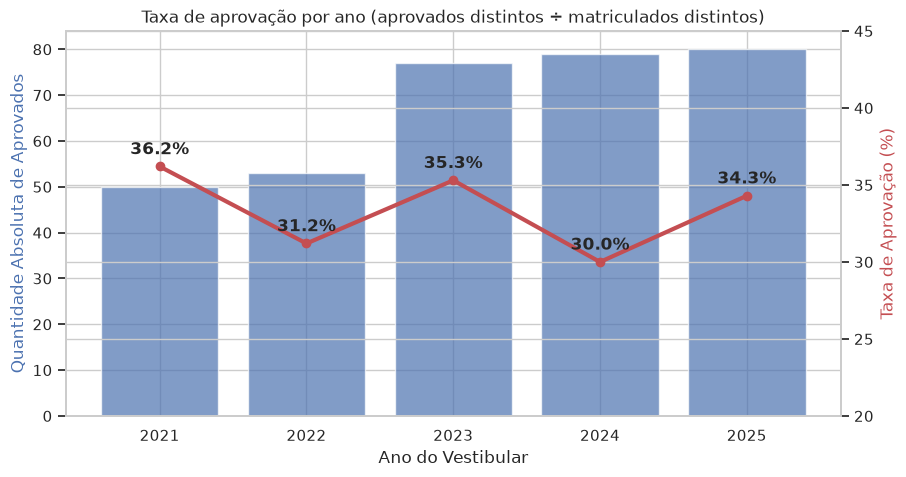

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Barras: Total de aprovados distintos
ax1.bar(df_q1["ano"], df_q1["(3) Aprovados distintos"], color="#4C72B0", alpha=0.7, label="Aprovados Distintos")
ax1.set_ylabel("Quantidade Absoluta de Aprovados", color="#4C72B0")
ax1.set_xlabel("Ano do Vestibular")

# Linha: Taxa de aprovação %
taxa_num = df_q1["Taxa de Aprovação = (3 ÷ 1)"].str.rstrip("%").astype(float)
ax2 = ax1.twinx()
ax2.plot(df_q1["ano"], taxa_num, color="#C44E52", marker="o", linewidth=3, label="Taxa de Aprovação (%)")
ax2.set_ylabel("Taxa de Aprovação (%)", color="#C44E52")
ax2.set_ylim(20, 45)

for i, txt in enumerate(taxa_num):
    ax2.annotate(f"{txt}%", (df_q1["ano"][i], taxa_num[i] + 0.8), ha='center', fontweight='bold')

plt.title("Taxa de aprovação por ano (aprovados distintos ÷ matriculados distintos)")
plt.show()

### Comentário da Pergunta 1:
- **Crescimento Absoluto**: O volume absoluto de alunos aprovados cresceu **60%**, passando de **50 aprovados** em 2021 para **80 aprovados** em 2025.
- **Estabilidade Relativa**: A taxa de aprovação percentual oscilou entre **30,0% e 36,2%**, indicando que a capacidade de conversão do cursinho manteve-se sólida mesmo com a forte expansão da base total de alunos.

--- 
## Pergunta 2: Existe relação entre presença nas aulas e aprovação no vestibular?

Calculei a frequência escolar individual (porcentagem de presença) de cada aluno a partir da tabela `presencas_aulas` e comparei o grupo de aprovados com o grupo de não aprovados.

In [4]:
with sqlite3.connect(DB_PATH) as conn:
    df_pres = pd.read_sql_query("""
        SELECT aluno_id, 
               COUNT(*) as total_aulas,
               SUM(CASE WHEN status_presenca IN ('Presente', 'Atrasado') THEN 1 ELSE 0 END) as presencas,
               ROUND(SUM(CASE WHEN status_presenca IN ('Presente', 'Atrasado') THEN 1.0 ELSE 0.0 END) / COUNT(*) * 100, 2) as pct_presenca
        FROM presencas_aulas
        GROUP BY aluno_id
    """, conn)

    df_aprov_alunos = pd.read_sql_query("SELECT DISTINCT aluno_id FROM aprovacoes_vestibular", conn)
    df_aprov_alunos["aprovado"] = 1

df_q2 = pd.merge(df_pres, df_aprov_alunos, on="aluno_id", how="left")
df_q2["aprovado"] = df_q2["aprovado"].fillna(0).astype(int)
df_q2["Status"] = df_q2["aprovado"].map({1: "Aprovado", 0: "Não Aprovado"})

display(df_q2.groupby("Status")["pct_presenca"].describe().round(2))

,count,mean,std,min,25%,50%,75%,max
Status,,,,,,,,
Aprovado,306.0,83.97,3.84,73.17,81.61,83.97,86.32,95.00
Não Aprovado,494.0,84.03,4.26,70.31,81.39,84.21,86.76,97.14


/tmp/ipykernel_58935/2888444042.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_q2, x="Status", y="pct_presenca", palette=["#C44E52", "#55A868"])


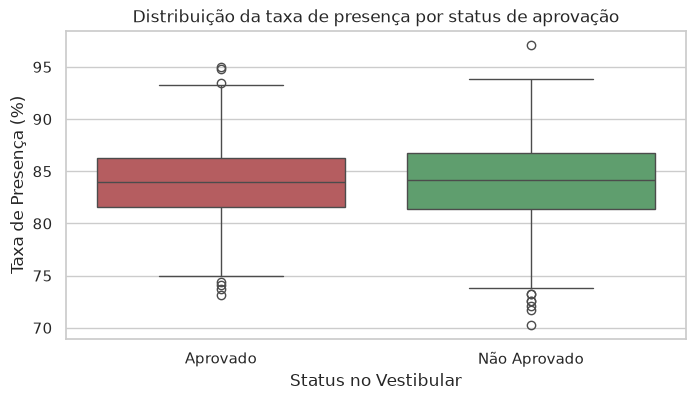

In [5]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_q2, x="Status", y="pct_presenca", palette=["#C44E52", "#55A868"])
plt.title("Distribuição da taxa de presença por status de aprovação")
plt.ylabel("Taxa de Presença (%)")
plt.xlabel("Status no Vestibular")
plt.show()

### Comentário da Pergunta 2:
- A frequência média em aula é praticamente a mesma entre os dois grupos: **83,97% nos Aprovados** vs **84,03% nos Não Aprovados**.
- **Conclusão de Negócio**: a presença isolada não garante a aprovação. Fatores como rendimento prático em simulados, horas de estudo individual e fixação de conteúdos em disciplinas exatas exercem papel diferenciador.

--- 
## Pergunta 3: Quais cursos ou matérias parecem apresentar melhor desempenho?

Análise do desempenho acadêmico dos alunos por disciplina nos simulados e dos cursos universitários com maior índice de aprovação.

In [6]:
# Desempenho em Simulados por Matéria (Média de Notas)
with sqlite3.connect(DB_PATH) as conn:
    df_q3_mat = pd.read_sql_query("""
        SELECT s.materia, 
               COUNT(r.resultado_id) as total_realizacoes,
               ROUND(AVG(r.nota), 2) as media_nota,
               ROUND(AVG(r.acertos), 2) as media_acertos
        FROM resultados_simulados r
        JOIN simulados s ON r.simulado_id = s.simulado_id
        WHERE r.status_realizacao = 'Finalizado'
        GROUP BY s.materia
        ORDER BY media_nota DESC
    """, conn)

display(df_q3_mat)

,materia,total_realizacoes,media_nota,media_acertos
0,Redação,1613,718.65,NaN
1,Inglês,1537,63.25,31.42
2,História,1677,62.92,29.76
3,Português,1663,62.74,32.85
4,Geografia,1623,62.69,28.37
5,Biologia,1695,62.66,31.66
6,Filosofia,1586,62.62,29.33
7,Sociologia,1670,62.33,27.22
8,Química,1685,62.14,24.01
9,Física,1818,62.09,32.21


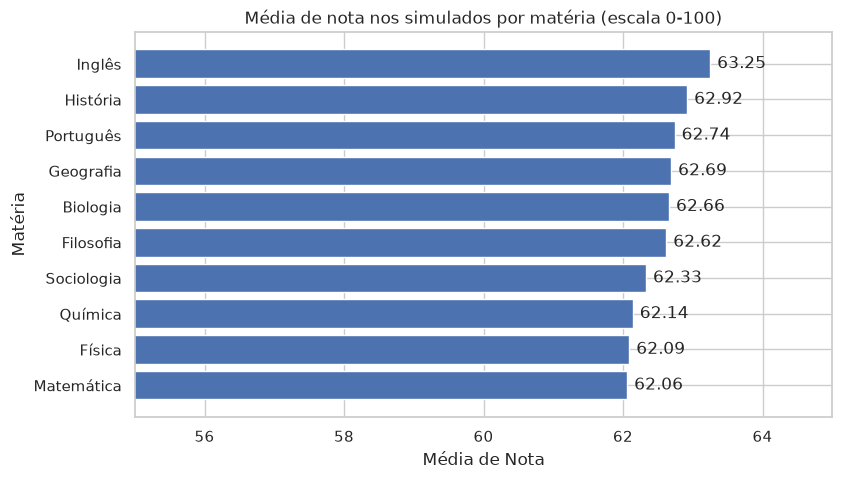

In [7]:
# Gráfico do desempenho em matérias objetivas (excluindo Redação que usa escala 0-1000)
df_objetivas = df_q3_mat[df_q3_mat["materia"] != "Redação"].sort_values("media_nota", ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(df_objetivas["materia"], df_objetivas["media_nota"], color="#4C72B0")
plt.xlim(55, 65)
plt.title("Média de nota nos simulados por matéria (escala 0-100)")
plt.xlabel("Média de Nota")
plt.ylabel("Matéria")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center')

plt.show()

In [8]:
# Top 10 Cursos Universitários com Mais Aprovados
with sqlite3.connect(DB_PATH) as conn:
    df_q3_cursos = pd.read_sql_query("""
        SELECT curso_aprovado, 
               COUNT(*) as total_aprovacoes, 
               COUNT(DISTINCT aluno_id) as alunos_unicos
        FROM aprovacoes_vestibular
        GROUP BY curso_aprovado
        ORDER BY total_aprovacoes DESC
        LIMIT 10
    """, conn)

display(df_q3_cursos)

,curso_aprovado,total_aprovacoes,alunos_unicos
0,Enfermagem,28,28
1,Odontologia,27,27
2,Engenharia de Software,27,27
3,Arquitetura,27,27
4,Engenharia Civil,26,26
5,Direito,26,26
6,Design,25,25
7,Medicina,24,24
8,Economia,24,24
9,Administração,24,24


--- 
## Análises extras estratégicas: canais de captação e escola de origem

Análises complementares para apoiar os times de **Marketing, Vendas e Gestão Pedagógica**.

,canal_captacao,total_estudantes,aprovados_unicos,taxa_aprovacao_pct
0,Indicação,106,46,43.40
1,Google,126,51,40.48
2,Feira Escolar,105,41,39.05
3,Instagram,238,82,34.45
4,Whatsapp,106,33,31.13


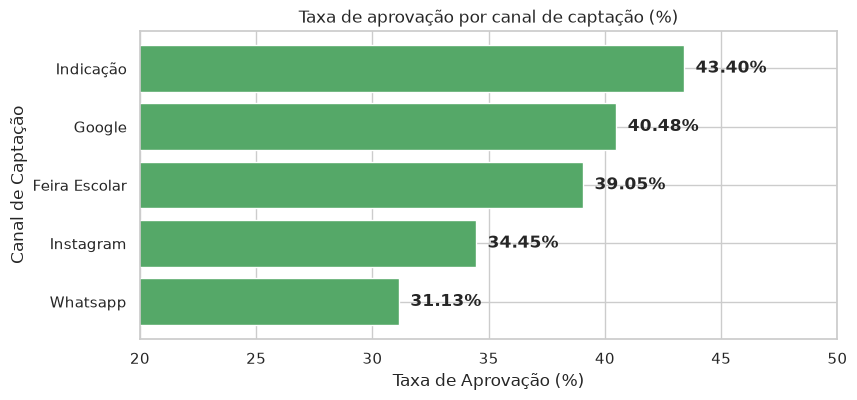

In [9]:
# Análise Extra 1: Eficiência dos canais de captação
with sqlite3.connect(DB_PATH) as conn:
    df_canal = pd.read_sql_query("""
        SELECT e.canal_captacao,
               COUNT(DISTINCT e.aluno_id) as total_estudantes,
               COUNT(DISTINCT a.aluno_id) as aprovados_unicos,
               ROUND(COUNT(DISTINCT a.aluno_id) * 100.0 / COUNT(DISTINCT e.aluno_id), 2) as taxa_aprovacao_pct
        FROM estudantes e
        LEFT JOIN aprovacoes_vestibular a ON e.aluno_id = a.aluno_id
        WHERE e.canal_captacao != 'Não Informado'
        GROUP BY e.canal_captacao
        ORDER BY taxa_aprovacao_pct DESC
    """, conn)

display(df_canal)

plt.figure(figsize=(9, 4))
bars = plt.barh(df_canal["canal_captacao"], df_canal["taxa_aprovacao_pct"], color="#55A868")
plt.xlim(20, 50)
plt.title("Taxa de aprovação por canal de captação (%)")
plt.xlabel("Taxa de Aprovação (%)")
plt.ylabel("Canal de Captação")

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.5, bar.get_y() + bar.get_height()/2, f'{w:.2f}%', va='center', fontweight='bold')

plt.gca().invert_yaxis()
plt.show()

,escola_origem,total_estudantes,aprovados_unicos,taxa_aprovacao_pct
0,Privada,248,99,39.92
1,Pública,227,83,36.56
2,Federal,112,40,35.71


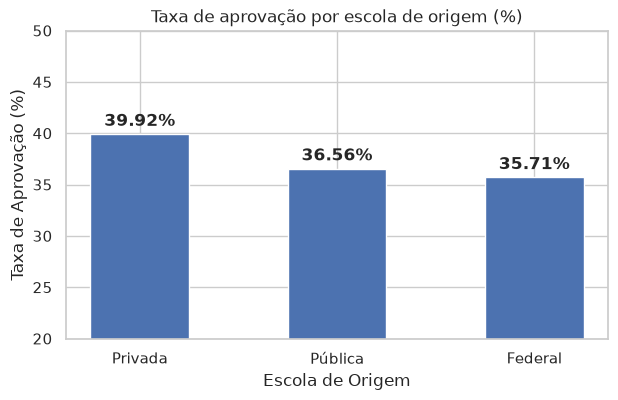

In [10]:
# Análise Extra 2: Impacto da Escola de Origem na Taxa de Aprovação
with sqlite3.connect(DB_PATH) as conn:
    df_esc = pd.read_sql_query("""
        SELECT e.escola_origem,
               COUNT(DISTINCT e.aluno_id) as total_estudantes,
               COUNT(DISTINCT a.aluno_id) as aprovados_unicos,
               ROUND(COUNT(DISTINCT a.aluno_id) * 100.0 / COUNT(DISTINCT e.aluno_id), 2) as taxa_aprovacao_pct
        FROM estudantes e
        LEFT JOIN aprovacoes_vestibular a ON e.aluno_id = a.aluno_id
        WHERE e.escola_origem != 'Não Informado'
        GROUP BY e.escola_origem
        ORDER BY taxa_aprovacao_pct DESC
    """, conn)

display(df_esc)

plt.figure(figsize=(7, 4))
bars = plt.bar(df_esc["escola_origem"], df_esc["taxa_aprovacao_pct"], color="#4C72B0", width=0.5)
plt.ylim(20, 50)
plt.title("Taxa de aprovação por escola de origem (%)")
plt.ylabel("Taxa de Aprovação (%)")
plt.xlabel("Escola de Origem")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.8, f'{h:.2f}%', ha='center', fontweight='bold')

plt.show()

### Comentário da Pergunta 3:
- **Destaques Positivos**: **Inglês (63.25)** e **História (62.92)** apresentam as maiores médias de notas nos simulados.
- **Menores Médias**: **Matemática (62.06)**, **Física (62.09)** e **Química (62.14)** registram as menores notas médias nos simulados, apontando o bloco de Exatas/Natureza como a principal fragilidade dos estudantes.
- **Cursos Mais Aprovados**: Enfermagem, Odontologia, Engenharia de Software e Arquitetura lideram o ranking de aprovações universitárias.

--- 
## Pergunta 4: Quais recomendações você faria para a coordenação do cursinho?

Com base nos dados analisados, apresento **4 recomendações estratégicas acionáveis**:

1. **Reforço Focado no Bloco de Exatas e Natureza**: Criar oficinas e turmas de apoio específicas para *Matemática, Física e Química*, que demonstraram as menores notas médias históricas nos simulados.
2. **Monitoramento Preditivo do Aluno (Além da Presença)**: Implementar alertas precoces baseados nas notas de simulados. Como a presença média é alta (84%) mesmo entre não aprovados, a coordenação não pode depender apenas da lista de frequência para diagnosticar risco pedagógico.
3. **Manutenção da Excelência em Redação e Humanas**: Redação e História/Inglês são alavancadores de nota; manter as oficinas de escrita e simulados temáticos.
4. **Direcionamento por Carreira**: Oferecer simulados com pesos específicos da banca para alunos focados nos cursos mais concorridos do cursinho (Engenharia de Software, Odontologia, Enfermagem e Direito).